### Build A Basic Chatbot With Langgraph(GRAPH API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
from langchain_ollama import ChatOllama

# llm=ChatGroq(model="llama3-8b-8192")
llm = ChatOllama(model="llama3.2")

In [5]:
llm

ChatOllama(output_version=None, model='llama3.2')

In [6]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [7]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

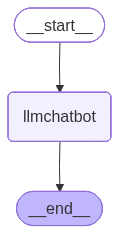

In [8]:
# Visualize the graph

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
response = graph.invoke({"messages":[{"role":"user","content":"What is the capital of France?"}]})

In [10]:
response["messages"][-1].content

'The capital of France is Paris.'

In [11]:
for event in graph.stream({"messages": [{"role": "user", "content": "Hi How are you?"}]}):
    for value in event.values():
        print(value["messages"][-1].content)
   

I'm just a language model, so I don't have emotions or feelings in the way that humans do. However, I'm functioning properly and ready to help with any questions or tasks you may have! How can I assist you today?


### Chatbot With Tool

Here is the **description-only version** (no code), cleaned up so you can copy it directly into notes.

---

# LangGraph Tool Calling Workflow (Step by Step)

This workflow builds an AI agent where the model can **decide whether it needs to use external tools** (such as web search or custom functions) before giving an answer.

Overall flow:

**User → LLM → Decide if tool needed → Execute tool → Return response**

---

## 1. Create Tools

First, we define tools that the AI agent can use.

Examples:

* Web search tool (Tavily Search)
* Custom function (such as multiplication)

Purpose:

The tools extend the LLM’s capabilities beyond normal text generation.

Without tools:

* LLM can only answer from its training data.

With tools:

* LLM can search the internet.
* LLM can execute functions.
* LLM can interact with external systems.

---

## 2. Store Tools in a List

All tools are grouped together.

Purpose:

This creates a collection of available actions for the LLM.

At this point, the system knows:

* Tool 1 = Web Search
* Tool 2 = Multiply Function

Think of it like giving the AI a toolbox.

---

## 3. Bind Tools to the LLM

The tools are attached to the language model.

Purpose:

This allows the LLM to decide when a tool should be used.

Before binding:

* LLM only generates text responses.

After binding:

* LLM can decide:

  * Answer directly
  * Use a tool first

Example decisions:

If user asks factual information:

* Use web search tool

If user asks mathematical calculation:

* Use multiply tool

---

## 4. Create State Management

A state is created to store conversation history.

Purpose:

The system needs memory of all previous messages.

The state stores:

* User messages
* AI responses
* Tool outputs

This conversation history is passed through the graph.

Important concept:

Messages should be appended continuously rather than replacing old messages.

This helps maintain conversation context.

---

## 5. Create LLM Node

A node is created that sends messages to the language model.

Purpose:

The LLM analyzes user input and decides what action to take.

Possible decisions:

### Case 1: Tool required

Example:

User asks to multiply numbers.

LLM decides:

“I need to call the multiply tool.”

### Case 2: Tool not required

Example:

User says hello.

LLM decides:

“I can answer directly without any tool.”

So this node acts as the decision-making brain.

---

## 6. Create Graph

A graph is created to define workflow.

Purpose:

The graph controls how information moves between nodes.

Think of it as a flowchart.

A graph consists of:

* Nodes → Actions
* Edges → Connections between actions

---

## 7. Add LLM Node to Graph

The LLM node is added into the workflow.

Purpose:

This node becomes the main decision-maker.

Its job:

* Read user input
* Decide whether a tool is needed

This is the first processing step.

---

## 8. Add Tool Node

A Tool Node is added.

Purpose:

Its job is to execute tools automatically whenever the LLM requests them.

If LLM says:

“I need to use multiply function”

The Tool Node executes that function.

If LLM says:

“I need to search the web”

The Tool Node performs web search.

This node acts as the execution engine.

---

## 9. Add Starting Edge

The graph needs a starting point.

Purpose:

Define where execution begins.

Flow:

When user sends input → send it first to the LLM node.

This means every request begins with decision-making.

---

## 10. Add Conditional Routing

A conditional edge checks the LLM output.

Purpose:

Determine whether tool execution is needed.

The system checks:

“Did the LLM request a tool call?”

Two possibilities exist.

---

### Path 1: Tool Needed

If the LLM requests a tool:

Flow becomes:

User Input → LLM → Tool Execution

Example:

User asks for multiplication.

LLM decides:

“Use multiply tool”

System routes to Tool Node.

---

### Path 2: Tool Not Needed

If the LLM does not request any tool:

Flow becomes:

User Input → LLM → End

Example:

User says hello.

LLM answers directly.

No tool execution happens.

---

## 11. Add Edge After Tool Execution

After a tool finishes execution, the graph moves to the next step.

In your graph:

After tool execution → workflow ends.

Purpose:

Stop execution after tool finishes.

Current flow:

LLM → Tool → End

---

## 12. Compile Graph

Compiling converts the graph into an executable workflow.

Purpose:

Turn the graph design into a runnable system.

Before compile:

* Graph is only a blueprint.

After compile:

* Graph becomes executable.

---

# How Entire Workflow Works

The complete execution flow is:

1. User sends a message.

2. Message goes to the LLM.

3. LLM analyzes the request.

4. LLM decides:

   * Can I answer directly?
   * Do I need a tool?

5. If no tool needed:

   * Return response directly.
   * End workflow.

6. If tool needed:

   * Route request to Tool Node.

7. Tool Node executes the requested tool.

8. Return tool result.

9. End workflow.

---


# Important Limitation in Current Graph

In your current design:

After tool execution → graph immediately ends.

Problem:

The LLM never sees the tool result.

Current flow:

LLM → Tool → End

This means:

* Tool executes successfully.
* But LLM cannot convert result into a natural language response.

Example:

User asks multiplication.

System:

* LLM requests multiply tool
* Tool returns 6
* Graph ends immediately

The LLM never says:

“The answer is 6”

---

# Better Architecture

A better design is:

After tool executes, send result back to LLM again.

New flow:

LLM → Tool → LLM → End

Why better?

Because now:

* Tool executes
* Result goes back to LLM
* LLM creates final human-friendly response

Example:

User asks multiplication.

Flow:

* LLM decides tool needed
* Tool calculates result
* Result goes back to LLM
* LLM says:

“The multiplication result is 6”

Then workflow ends.

---

# Final Summary of Components

### Tools

Provide external capabilities such as:

* Web search
* Math functions
* API calls

### LLM

Acts as the decision maker.

Determines whether tools are required.

### State

Stores conversation history.

Maintains context.

### Graph

Defines workflow structure.

Controls execution flow.

### Nodes

Represent actions.

Examples:

* LLM Node
* Tool Node

### Edges

Connect nodes together.

Control movement between steps.

### Conditional Routing

Checks whether a tool call exists.

Decides next path dynamically.

### Tool Node

Executes requested tools automatically.

### Compile

Converts workflow design into executable graph.

---

Core idea:

**LLM first thinks → decides if tool is needed → tool executes → result returned → final response generated**

This is the foundation of tool-calling agents in **LangGraph**.


In [12]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is LangGraph?")

{'query': 'What is LangGraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the 

In [13]:

## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [14]:
tools = [tool, multiply]

In [15]:
llm_with_tools = llm.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatOllama(output_version=None, model='llama3.2'), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'string'}, 'type': 'array'}, {'type': 'null'}], 'default': [], 'description': 'A list of domains to restrict search results to.\n\n        Use this parameter when:\n        1. The user explicitly requests information from specific websites (e.g., "Find climate data from nasa.gov")\n        2. The user m

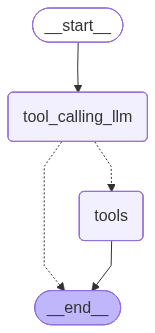

In [16]:

## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


    

# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
response=graph.invoke({"messages":"Search AI news from this week"})

In [18]:
response['messages'][-1].content

'{"query": "AI news this week", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/06/08/ai-news-nvidia-cosmos-3-openai-sites-solara-rtx-spark", "title": "Axios C-Suite: 3 new AI developments for the week of June 6 - Axios", "score": 0.8624794, "published_date": "Mon, 08 Jun 2026 09:57:05 GMT", "content": "# Axios C-Suite: 3 new AI developments for the week of June 6. Fast action AI software:** OpenAI launched Sites, a Codex feature that lets your staff create, host and deploy work-related web apps from prompts internally —\xa0instantly. * **Why it matters:** Custom software usually requires vendor contracts, engineering time or a long IT queue. AI\'s cheaper future:** Nvidia\'s RTX Spark and Microsoft\'s Project Solara aim to move AI inference from the cloud onto personal devices. * **Why it matters:** Companies are starting to ration AI as token costs rise. Physical AI\'s GPT moment:** Nvidia unveiled Cosmos 3, a foundation mode

In [19]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Search AI news from this week
================================== Ai Message ==================================
Tool Calls:
  tavily_search (c5437b66-6297-4d4c-a942-417dbe2e2a0e)
 Call ID: c5437b66-6297-4d4c-a942-417dbe2e2a0e
  Args:
    query: AI news this week
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news this week", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/06/08/ai-news-nvidia-cosmos-3-openai-sites-solara-rtx-spark", "title": "Axios C-Suite: 3 new AI developments for the week of June 6 - Axios", "score": 0.8624794, "published_date": "Mon, 08 Jun 2026 09:57:05 GMT", "content": "# Axios C-Suite: 3 new AI developments for the week of June 6. Fast action AI software:** OpenAI launched Sites, a Codex feature that lets your staff crea

In [20]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (1d78c2d9-99af-439c-a331-cbd3f1e3be39)
 Call ID: 1d78c2d9-99af-439c-a331-cbd3f1e3be39
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [21]:
response=graph.invoke({"messages":"Search AI news from this week and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Search AI news from this week and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (caea93d1-e7c5-4525-a08d-a5d0f78007fe)
 Call ID: caea93d1-e7c5-4525-a08d-a5d0f78007fe
  Args:
    query: AI news this week
    time_range: week
    topic: news
  multiply (e2e95f15-29b5-4c1a-8d3d-497dcad26d78)
 Call ID: e2e95f15-29b5-4c1a-8d3d-497dcad26d78
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news this week", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/06/08/ai-news-nvidia-cosmos-3-openai-sites-solara-rtx-spark", "title": "Axios C-Suite: 3 new AI developments for the week of June 6 - Axios", "score": 0.8624794, "published_date": "Mon, 08 Jun 2026 09:57:05 GMT", "content": "# Ax

### ReAct Agent Architecture

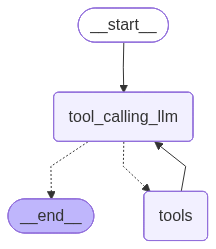

In [22]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [23]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (ecde56db-5019-43a8-92b9-c86382c2364f)
 Call ID: ecde56db-5019-43a8-92b9-c86382c2364f
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10
================================== Ai Message ==================================

The answer to the original question, "What is 5 multiplied by 2?" is 10.


In [24]:
response=graph.invoke({"messages":"Search AI news from this week and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Search AI news from this week and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (5163cf4d-ac70-4e99-9d47-ad237172b95c)
 Call ID: 5163cf4d-ac70-4e99-9d47-ad237172b95c
  Args:
    include_images: True
    start_date: None
    search_depth: advanced
    query: AI news this week
    end_date: 2024-03-31
    time_range: week
    include_domains: None
  multiply (5882bdca-dddf-4c05-870a-132c07221fcf)
 Call ID: 5882bdca-dddf-4c05-870a-132c07221fcf
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{'error': ValueError('Error 400: When time_range is set, start_date or end_date cannot be set')}
================================= Tool Message =================================
Name: multiply

50
================================== Ai Message ================

In [25]:
response=graph.invoke({"messages":"Search AI news from this week and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Search AI news from this week and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (1c88cd9e-cb9c-4405-9a97-c65abdc62bd7)
 Call ID: 1c88cd9e-cb9c-4405-9a97-c65abdc62bd7
  Args:
    query: AI news this week
    time_range: week
    topic: news
  multiply (9b7ea1aa-cff6-44c5-a8d6-f3d32e4d004c)
 Call ID: 9b7ea1aa-cff6-44c5-a8d6-f3d32e4d004c
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news this week", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/06/08/ai-news-nvidia-cosmos-3-openai-sites-solara-rtx-spark", "title": "Axios C-Suite: 3 new AI developments for the week of June 6 - Axios", "score": 0.8624794, "published_date": "Mon, 08 Jun 2026 09:57:05 GMT", "content": "# Ax

### Adding Memory In Agentic Graph

In [26]:
response=graph.invoke({"messages":"Hello my name is Rani"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Rani
================================== Ai Message ==================================
Tool Calls:
  tavily_search (67f75ce6-6d1c-47bc-92ba-0ce61d469e43)
 Call ID: 67f75ce6-6d1c-47bc-92ba-0ce61d469e43
  Args:
    end_date: None
    include_domains: None
    topic: general
    query: who is Rani
    exclude_domains: None
    include_images: False
    search_depth: basic
    start_date: None
    time_range: None
================================= Tool Message =================================
Name: tavily_search

{"query": "who is Rani", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://en.wikipedia.org/wiki/The_Rani", "title": "The Rani - Wikipedia", "content": "The Rani is a fictional character in the British science fiction television series Doctor Who. She is a recurring antagonist within the series.", "score": 0.8952393, "raw_content": null}, {"url":

In [27]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================
Tool Calls:
  tavily_search (727099ae-526c-4718-aa4a-c8b5421e30e2)
 Call ID: 727099ae-526c-4718-aa4a-c8b5421e30e2
  Args:
    time_range: None
    query: what is my name
    include_domains: None
    exclude_domains: None
    start_date: None
    topic: general
    include_images: False
    end_date: None
    search_depth: basic
================================= Tool Message =================================
Name: tavily_search

{"query": "what is my name", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.whatismyname.org", "title": "What is my Name", "content": "Search across 1,400+ platforms instantly and uncover where your username exists online. Enter a username above to search across 1,400+ platforms. # Username Search & Digital Identity. **WhatsMyName** is a sea

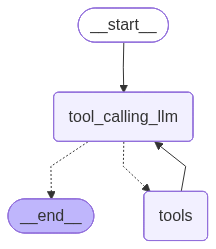

In [28]:
### Adding Memory In Agentic Graph (Memory Checkpoint)

## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [29]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Rani"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is Rani', additional_kwargs={}, response_metadata={}, id='a02d0336-8e47-4322-af22-58f8503c582c'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-06-12T17:50:01.854973Z', 'done': True, 'done_reason': 'stop', 'total_duration': 15612090700, 'load_duration': 407819000, 'prompt_eval_count': 1449, 'prompt_eval_duration': 943068000, 'eval_count': 73, 'eval_duration': 13928458000, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--019ebcf4-4781-7f90-abf6-a07f3be629eb-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'hi my name is Rani', 'end_date': None, 'exclude_domains': None, 'search_depth': 'general', 'time_range': None, 'start_date': None, 'include_domains': None, 'include_images': False, 'topic': 'general'}, 'id': '7a8f1dfb-dbf8-40e8-887e-bf3cfc5103d1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1449, 'ou

In [30]:
response['messages'][-1].content

"It seems like the tool required a more specific search depth to provide an accurate result.\n\nLet me try again with a different search depth.\n\nHi Rani, I'm happy to help you! Can you please tell me a little bit about yourself or what brings you here today?"

In [31]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Rani is a beautiful name with a rich history and meaning! In Sanskrit, it means "queen" or "she who rules," which makes it a strong and empowering choice for a given name. The name Rani has been popular in South Asian cultures, particularly in India, where it's associated with royalty and nobility. It's also mentioned as a feminine given name that resonates with charm and significance.

Interestingly, the name Rani is derived from Hebrew, meaning "Joyous song." This adds another layer of depth to the name, don't you think?

Overall, Rani is a lovely name with a rich history and meaning. I hope this helps!


In [32]:
response=graph.invoke({"messages":"Hey do you remember mmy name"},config=config)

print(response['messages'][-1].content)

It looks like I was able to find some information about your name, Rani! According to various sources, the name Rani has multiple origins and meanings. In Sanskrit, it means "queen" or "she who rules," while in Hebrew, it means "joyful song." The name also has Norse and Sanskrit roots, giving it a unique blend of cultures.

Some people believe that the name Rani is derived from the Old Norse name Hrani, meaning "rough" or "brutal," which adds an edgy side to the soft and melodic sound of the name. Others see it as a symbol of empowerment and nobility, reflecting the strong and regal qualities associated with the name.

I hope this helps you learn more about your name, Rani!


### Streaming

In [33]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [34]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

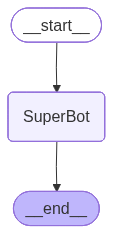

In [35]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges
graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)

graph_builder=graph.compile(checkpointer=memory)

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [36]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Rani And I like Chess"},config)

{'messages': [HumanMessage(content='Hi,My name is Rani And I like Chess', additional_kwargs={}, response_metadata={}, id='d8f4665f-4a05-4ba5-910c-1c05d09a9694'),
  AIMessage(content='Hello Rani! Nice to meet you. Chess is a great game that requires strategy and critical thinking. Are you an experienced player or just starting out? Do you have a favorite chess opening or closing move?', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-06-12T17:54:32.9319933Z', 'done': True, 'done_reason': 'stop', 'total_duration': 7529096000, 'load_duration': 477763700, 'prompt_eval_count': 36, 'prompt_eval_duration': 562486000, 'eval_count': 43, 'eval_duration': 6331643000, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--019ebcf8-89f9-7610-a4cd-a1baa6bb5426-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 43, 'total_tokens': 79})]}

Methods: .stream() and astream()

These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

values : This streams the full state of the graph after each node is called.
updates : This streams updates to the state of the graph after each node is called.

In [37]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Rani And I like Chess"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hello Rani! It's nice to meet you. Chess is a great game - it requires strategy and critical thinking. Do you have a favorite chess opening or do you prefer to play with different openings depending on the situation?\n\nAre you a beginner or an experienced player? Have you ever participated in any online chess tournaments or played against friends and family?", additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-06-12T17:54:44.0117604Z', 'done': True, 'done_reason': 'stop', 'total_duration': 11050964000, 'load_duration': 429240100, 'prompt_eval_count': 36, 'prompt_eval_duration': 140306000, 'eval_count': 71, 'eval_duration': 10470668000, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--019ebcf8-a77e-7c52-b89d-08446cf97dc4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 71, 'total_tokens': 107})]}}


In [38]:

for chunk in graph_builder.stream({'messages':"Hi,My name is Rani And I like Chess"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Rani And I like Chess', additional_kwargs={}, response_metadata={}, id='abe4ab57-ff7a-475f-8cef-4b11e9c6c572'), AIMessage(content="Hello Rani! It's nice to meet you. Chess is a great game - it requires strategy and critical thinking. Do you have a favorite chess opening or do you prefer to play with different openings depending on the situation?\n\nAre you a beginner or an experienced player? Have you ever participated in any online chess tournaments or played against friends and family?", additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-06-12T17:54:44.0117604Z', 'done': True, 'done_reason': 'stop', 'total_duration': 11050964000, 'load_duration': 429240100, 'prompt_eval_count': 36, 'prompt_eval_duration': 140306000, 'eval_count': 71, 'eval_duration': 10470668000, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--019ebcf8-a77e-7c52-b89d-08446cf97dc4-0', tool_calls=[], in

In [39]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Rani And I like Chess"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hello Rani! It's nice to meet you. Chess is a great game, isn't it? There's something strategic and intellectual about it that appeals to many people.\n\nAre you an experienced chess player or just starting out? Do you have a favorite opening or a go-to strategy?\n\n(And by the way, would you like to play a virtual game of chess with me?)", additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-06-12T17:55:13.6509522Z', 'done': True, 'done_reason': 'stop', 'total_duration': 13480439500, 'load_duration': 491562000, 'prompt_eval_count': 36, 'prompt_eval_duration': 150601000, 'eval_count': 78, 'eval_duration': 12810692000, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--019ebcf9-11c9-7223-ab1f-482782e60b29-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 78, 'total_tokens': 114})]}}


In [40]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Rani And I like Chess', additional_kwargs={}, response_metadata={}, id='e6c13e2c-cfc1-4fee-923c-a8ee5d5b39c4'), AIMessage(content="Hello Rani! It's nice to meet you. Chess is a great game, isn't it? There's something strategic and intellectual about it that appeals to many people.\n\nAre you an experienced chess player or just starting out? Do you have a favorite opening or a go-to strategy?\n\n(And by the way, would you like to play a virtual game of chess with me?)", additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-06-12T17:55:13.6509522Z', 'done': True, 'done_reason': 'stop', 'total_duration': 13480439500, 'load_duration': 491562000, 'prompt_eval_count': 36, 'prompt_eval_duration': 150601000, 'eval_count': 78, 'eval_duration': 12810692000, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--019ebcf9-11c9-7223-ab1f-482782e60b29-0', tool_calls=[], invalid_tool_calls=[], 

In [41]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Rani and I like to play Chess"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Rani and I like to play Chess']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ebcf9-aa60-72c0-b477-7cf4c0852054', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Rani and I like to play Chess', additional_kwargs={}, response_metadata={}, id='86a3ef63-2133-44dd-a6e4-d861c5c4f227')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019ebcf9-aa64-7e93-ab61-484c93c2a8d7', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:cbc12e09-072a-524b-5031-0097ab98db4c'}, 'parent_ids': ['019ebcf9-aa60-72c0-b477-7cf4c0852054']}
{'event': 'on_chain_stream', 'run_id': '019ebcf9-aa64-7e93-ab61-484c9